In [1]:
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install scikit-learn

In [2]:
# pip freeze > ../requirements.txt

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
%matplotlib inline

In [4]:
# read csv file
df = pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


<Axes: xlabel='Weight', ylabel='Height'>

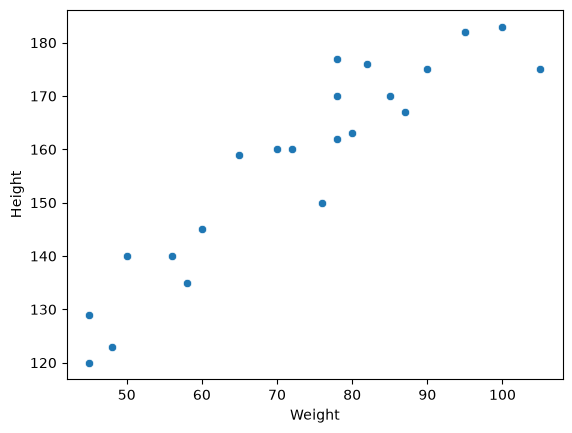

In [5]:
# checking in my dependent varaible and independent varaible are corealted or not
# 1. Scatter plot
sns.scatterplot(data=df,x="Weight",y='Height')

In [6]:
# 2. correlation matrix
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


### Always make sure that your Independent varaible is in form of Data frame(or 2d array) not in the form of Series(or 1d array)

In [10]:
# Independent and Dependent feature
X=df[["Weight"]] # it should be in Dataframe or 2dim array
y=df["Height"] # it can be in series or 1dim array

### Splitting data into train test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split( X, y, random_state=42, test_size=0.25)

In [14]:
X_train.shape

(17, 1)

### Standardization

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [17]:
X_test = scaler.transform(X_test)

### Applying Simple Linear Regression

In [18]:
# The linear regression used by linear_model is based on OLS (Oridinary Least Square) i.e direct computation of Thetas
from sklearn.linear_model import LinearRegression

In [22]:
linear_regression_ols = LinearRegression()

In [26]:
# This is my linear regression model , that has been trained on my training dataset
reg = linear_regression_ols.fit(X_train,y_train)

In [28]:
# Let look into coefficient and intercept
slope = reg.coef_
intercept = reg.intercept_
print("Slope", slope)
print("Intercept", intercept)

Slope [17.2982057]
Intercept 156.47058823529412


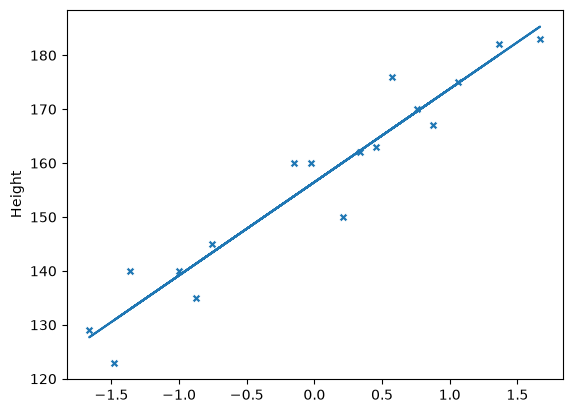

In [51]:
sns.scatterplot(x=X_train[:,0],y=y_train,marker="X")
plt.plot(X_train,(slope*X_train)+intercept)

In [57]:
# Prediction of test data
y_pred = reg.predict(X_test)

### Performance Matrix

In [56]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [60]:
# error are bascially calculated by y - y_hat
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

In [61]:
print("Mean absolute error :",mae)
print("Mean square error :", mse)
print("Root Mean square error :",rmse)

Mean absolute error : 9.66512588679501
Mean square error : 114.84069295228699
Root Mean square error : 10.716374991212605


In [62]:
score = reg.score(X_test,y_test)
print(score)
# An R2 score of approximately 0.736 means the model explains about 73.6% of the variation in the test heights.

0.7360826717981276


### Adjusted R2 Score
$$
R_{\text{adjusted}}^{2}
=
1-
\left(1-R^{2}\right)
\frac{n-1}{n-p-1}
$$

In [64]:
# Adjusted R2 score

adj_r2_score = 1 - (((1-score) * (len(y_test) - 1))/ (len(y_test)- X_test.shape[1] - 1))
print(adj_r2_score)

0.6701033397476595
